In [59]:
import warnings
# Suppress the specific SciPy/NumPy version warnings
warnings.filterwarnings('ignore', message='.*NumPy version.*')

In [60]:
# %%
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Step 1: Loading Processed Data...")

DATA_PROCESSED = os.path.join("..", "data", "processed")
file_path = os.path.join(DATA_PROCESSED, "processed_all_households_blind.csv")

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Missing {file_path}. Please run the 02_data_processing notebook first.")

df = pd.read_csv(file_path)
print(f"[SUCCESS] Loaded dataset: {df.shape[0]} households.")
print(f"[SUCCESS] Class Distribution:\n{df['TARGET_GAP'].value_counts(normalize=True)*100}")

Step 1: Loading Processed Data...
[SUCCESS] Loaded dataset: 7450 households.
[SUCCESS] Class Distribution:
TARGET_GAP
True     66.161074
False    33.838926
Name: proportion, dtype: float64


In [61]:
# %%
print("Step 2: Splitting Data (70% Train, 15% Validate, 15% Test)...")

# Define features (X) and target (y)
# We drop SERIALNO (ID) and PUMA (Geography) as they are not standard numerical proxies. Also drop poverty gap as it is directly related to y.
X = df.drop(columns=['SERIALNO', 'PUMA', 'TARGET_GAP','POVERTY_GAP'])
y = df['TARGET_GAP']

# 1st Split: 70% Train, 30% Temporary Holdout (Val + Test)
# stratify=y ensures the small "Gap" class is distributed evenly across the splits
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 2nd Split: Split the 30% holdout exactly in half (15% Validate, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"[SUCCESS] Training set:   {X_train.shape[0]} rows")
print(f"[SUCCESS] Validation set: {X_val.shape[0]} rows")
print(f"[SUCCESS] Test set:       {X_test.shape[0]} rows")

# Apply Oversampling as data is highly imbalanced
from imblearn.over_sampling import SMOTE
from collections import Counter

print("\n[INFO] Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

print("[INFO] After SMOTE:", Counter(y_train_over))


Step 2: Splitting Data (70% Train, 15% Validate, 15% Test)...
[SUCCESS] Training set:   5215 rows
[SUCCESS] Validation set: 1117 rows
[SUCCESS] Test set:       1118 rows

[INFO] Before SMOTE: Counter({True: 3450, False: 1765})
[INFO] After SMOTE: Counter({False: 3450, True: 3450})


In [62]:
# %%
print("Step 3: Scaling Features and Training Baseline Model...")

# Features like NUM_CHILDREN (0-5) and GRPIP (Rent % 0-100) are on different scales.
# Logistic Regression requires them to be standardized.
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent data leakage from the validation/test sets
X_train_scaled = scaler.fit_transform(X_train_over)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Initialize the model
# class_weight='balanced' is critical here. Since the Gap is a minority class in the general population,
# this forces the model to heavily penalize missing a Gap household.
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Train the model
model.fit(X_train_scaled, y_train_over)

print("[SUCCESS] Logistic Regression Model trained successfully!")

Step 3: Scaling Features and Training Baseline Model...
[SUCCESS] Logistic Regression Model trained successfully!


Step 4: Evaluating on Validation Set...

--- Classification Report ---
                precision    recall  f1-score   support

Not in Gap (0)       0.57      0.68      0.62       378
   The Gap (1)       0.82      0.73      0.77       739

      accuracy                           0.72      1117
     macro avg       0.69      0.71      0.70      1117
  weighted avg       0.73      0.72      0.72      1117

--- ROC-AUC Score ---
0.7702



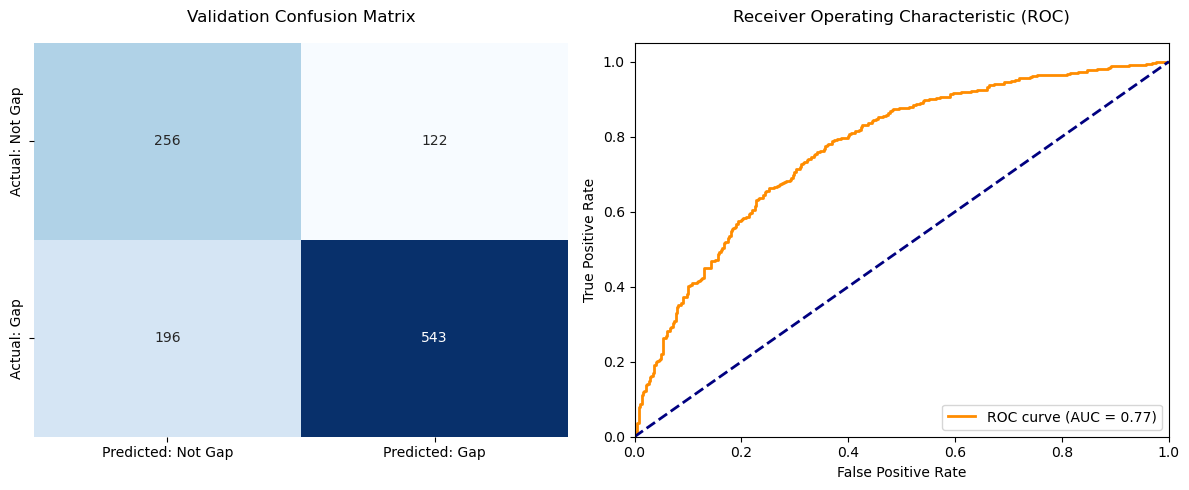

In [63]:
# %%
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 4: Evaluating on Validation Set...")

# Predict classes (0 or 1) and probabilities (for ROC-AUC)
y_val_pred = model.predict(X_val_scaled)
y_val_probs = model.predict_proba(X_val_scaled)[:, 1] # Get probabilities for Class 1 (The Gap)

# 1. Classification Report
print("\n--- Classification Report ---")
# 0 = Not in Gap, 1 = The Gap
print(classification_report(y_val, y_val_pred, target_names=["Not in Gap (0)", "The Gap (1)"]))

# 2. ROC-AUC Score
auc_score = roc_auc_score(y_val, y_val_probs)
print(f"--- ROC-AUC Score ---\n{auc_score:.4f}\n")

# 3. Visualizations: Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Predicted: Not Gap", "Predicted: Gap"],
            yticklabels=["Actual: Not Gap", "Actual: Gap"], ax=axes[0])
axes[0].set_title('Validation Confusion Matrix', pad=15)

# Plot B: ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random-guess line
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)', pad=15)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

Step 5: Analyzing the Proxies (What predicts the Gap?)

POSITIVE Coefficients: Higher values in this feature INCREASE the likelihood of being in the Gap.
NEGATIVE Coefficients: Higher values in this feature DECREASE the likelihood of being in the Gap.



,Feature,Coefficient
3,NUM_WORKING_ADULTS,0.699438
13,RENT_BURDEN,0.547354
6,VEH,0.499016
14,IS_OWNER,0.480829
4,MAX_EDUCATION,0.349569
24,AMENITY_COUNT,0.313038
16,WEALTH_INCOME_RATIO,0.262293
23,HOUSING_QUALITY_INDEX,0.251772
0,HAS_ELDERLY,0.249613
25,LOW_AMENITIES,0.196298


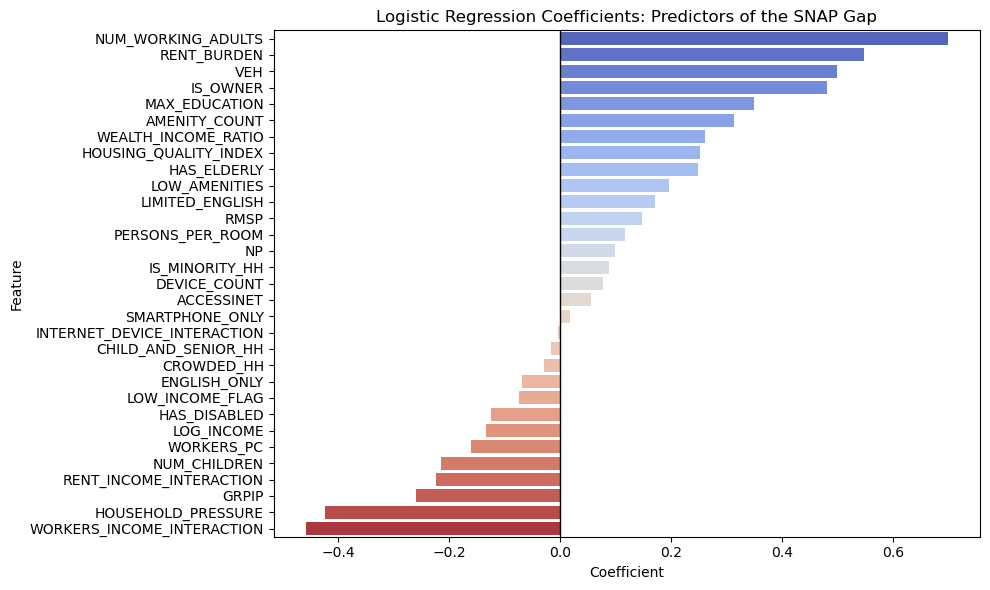

In [64]:
# %%
print("Step 5: Analyzing the Proxies (What predicts the Gap?)")

# Extract coefficients and map them back to the original feature names
coefficients = model.coef_[0]
feature_names = X.columns

# Create a clean DataFrame
df_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by impact
df_coef = df_coef.sort_values(by='Coefficient', ascending=False)

print("\nPOSITIVE Coefficients: Higher values in this feature INCREASE the likelihood of being in the Gap.")
print("NEGATIVE Coefficients: Higher values in this feature DECREASE the likelihood of being in the Gap.\n")

display(df_coef)

# Optional Visual Plot of the Coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=df_coef, palette='coolwarm')
plt.title('Logistic Regression Coefficients: Predictors of the SNAP Gap')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

In [65]:
# %%
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

print("[INIT] Step 6: Setting up Advanced Models and Validation Split...")

# To tune specifically on the validation set without cross-validation leakage,
# we combine the train and validation sets and use PredefinedSplit.
X_tune = np.vstack((X_train_scaled, X_val_scaled))
y_tune = np.concatenate((y_train_over, y_val))

# Create a list where -1 means "Training Data" and 0 means "Validation Data"
test_fold = [-1] * len(X_train_scaled) + [0] * len(X_val_scaled)
ps = PredefinedSplit(test_fold)

print("[SUCCESS] PredefinedSplit created. Training rows:", len(X_train_scaled), "| Validation rows:", len(X_val_scaled))

[INIT] Step 6: Setting up Advanced Models and Validation Split...
[SUCCESS] PredefinedSplit created. Training rows: 6900 | Validation rows: 1117


In [66]:
# %%
print("[PROCESS] Step 7: Tuning Random Forest Classifier...")

# Define the baseline model (balanced weights are critical here)
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# Define the hyperparameter grid to search
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Setup RandomizedSearch optimizing for ROC-AUC
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=15,               # Number of random combinations to try
    scoring='roc_auc',       # Optimize for the area under the ROC curve
    cv=ps,                   # Use our explicit Validation set
    random_state=42,
    n_jobs=-1,               # Use all CPU cores
    verbose=1
)

rf_search.fit(X_tune, y_tune)

# Extract the best model from the search
best_rf = rf_search.best_estimator_

# FIX: Force the model to retrain ONLY on the training data so the Validation set remains hidden!
best_rf.fit(X_train_scaled, y_train_over)

print(f"\n[SUCCESS] Best Random Forest AUC on Validation: {rf_search.best_score_:.4f}")
print(f"[INFO] Best RF Parameters: {rf_search.best_params_}")

[PROCESS] Step 7: Tuning Random Forest Classifier...
Fitting 1 folds for each of 15 candidates, totalling 15 fits

[SUCCESS] Best Random Forest AUC on Validation: 0.8148
[INFO] Best RF Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


In [67]:
print("[PROCESS] Step 8: Tuning LightGBM Classifier...")

import warnings
warnings.filterwarnings("ignore")

# LightGBM handles class imbalance using the 'is_unbalance' parameter
lgb_base = lgb.LGBMClassifier(is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1)

# Define the hyperparameter grid
# LightGBM is prone to overfitting, so we control num_leaves and depth
lgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 50],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

lgb_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=lgb_param_grid,
    n_iter=20,               
    scoring='roc_auc',       
    cv=ps,                   
    random_state=42,
    verbose=1
)

lgb_search.fit(X_tune, y_tune)

best_lgb = lgb_search.best_estimator_
best_lgb.fit(X_train_scaled, y_train_over) # FIX
print(f"\n[SUCCESS] Best LightGBM AUC on Validation: {lgb_search.best_score_:.4f}")
print(f"[INFO] Best LGBM Parameters: {lgb_search.best_params_}")

[PROCESS] Step 8: Tuning LightGBM Classifier...
Fitting 1 folds for each of 20 candidates, totalling 20 fits

[SUCCESS] Best LightGBM AUC on Validation: 0.8188
[INFO] Best LGBM Parameters: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [68]:
# %%
import xgboost as xgb
import numpy as np

print("[PROCESS] Step 8: Tuning XGBoost Classifier...")

# XGBoost handles imbalance via scale_pos_weight (ratio of negative to positive instances)
# We calculate this dynamically based on your training labels
negative_count = np.sum(y_train == 0)
positive_count = np.sum(y_train == 1)
imbalance_ratio = negative_count / positive_count

# Initialize XGBoost base model
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc', # Aligns the internal evaluation with our scoring metric
    verbosity=0 # Suppresses warnings (equivalent to verbose=-1 in LightGBM)
)

# Define the hyperparameter grid
# We swap ‘num_leaves’ for ‘min_child_weight’ to control overfitting in XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=ps,
    random_state=42,
    verbose=1
)

# Fit the model
xgb_search.fit(X_tune, y_tune)

best_xgb = xgb_search.best_estimator_
best_xgb.fit(X_train_scaled, y_train_over) # FIX
print(f"\n[SUCCESS] Best XGBoost AUC on Validation: {xgb_search.best_score_:.4f}")
print(f"[INFO] Best XGBoost Parameters: {xgb_search.best_params_}")

[PROCESS] Step 8: Tuning XGBoost Classifier...
Fitting 1 folds for each of 20 candidates, totalling 20 fits

[SUCCESS] Best XGBoost AUC on Validation: 0.8164
[INFO] Best XGBoost Parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [69]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Create a composite score based on auc, precision, recall, and tracking F1
def compute_metrics(y_true, y_pred, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0) # Adding standard F1 for reporting
    
    score = 0.4 * auc + 0.2 * precision + 0.4 * recall  # Custom composite score
    
    return auc, precision, recall, f1, score

In [70]:
print("[EVAL] Step 9: Comparing Champion Models on the Validation Set...")

results = {}

# 1. Logistic Regression
y_prob_lr = model.predict_proba(X_val_scaled)[:, 1]
y_pred_lr = model.predict(X_val_scaled)

print("Classification report for Logistic")
print(classification_report(y_val, y_pred_lr, target_names=["Not in Gap (0)", "The Gap (1)"]))

auc_lr, prec_lr, rec_lr, f1_lr, score_lr = compute_metrics(y_val, y_pred_lr, y_prob_lr)
results['Logistic Regression'] = {
    'model': model,
    'auc': auc_lr,
    'precision': prec_lr,
    'recall': rec_lr,
    'f1': f1_lr,
    'score': score_lr
}


# 2. Random Forest
y_prob_rf = best_rf.predict_proba(X_val_scaled)[:, 1]
y_pred_rf = best_rf.predict(X_val_scaled)

print("Classification report for Random Forest")
print(classification_report(y_val, y_pred_rf, target_names=["Not in Gap (0)", "The Gap (1)"]))

auc_rf, prec_rf, rec_rf, f1_rf, score_rf = compute_metrics(y_val, y_pred_rf, y_prob_rf)
results['Random Forest'] = {
    'model': best_rf,
    'auc': auc_rf,
    'precision': prec_rf,
    'recall': rec_rf,
    'f1': f1_rf,
    'score': score_rf,
    'params': rf_search.best_params_
}


# 3. LightGBM
y_prob_lgb = best_lgb.predict_proba(X_val_scaled)[:, 1]
y_pred_lgb = best_lgb.predict(X_val_scaled)

print("Classification report for LightGBM")
print(classification_report(y_val, y_pred_lgb, target_names=["Not in Gap (0)", "The Gap (1)"]))

auc_lgb, prec_lgb, rec_lgb, f1_lgb, score_lgb = compute_metrics(y_val, y_pred_lgb, y_prob_lgb)
results['LightGBM'] = {
    'model': best_lgb,
    'auc': auc_lgb,
    'precision': prec_lgb,
    'recall': rec_lgb,
    'f1': f1_lgb,
    'score': score_lgb,
    'params': lgb_search.best_params_
}


# 4. XGBoost
y_prob_xgb = best_xgb.predict_proba(X_val_scaled)[:, 1]
y_pred_xgb = best_xgb.predict(X_val_scaled)

print("Classification report for XGB")
print(classification_report(y_val, y_pred_xgb, target_names=["Not in Gap (0)", "The Gap (1)"]))

auc_xgb, prec_xgb, rec_xgb, f1_xgb, score_xgb = compute_metrics(y_val, y_pred_xgb, y_prob_xgb)
results['XGBoost'] = {
    'model': best_xgb,
    'auc': auc_xgb,
    'precision': prec_xgb,
    'recall': rec_xgb,
    'f1': f1_xgb,
    'score': score_xgb,
    'params': xgb_search.best_params_
}

[EVAL] Step 9: Comparing Champion Models on the Validation Set...
Classification report for Logistic
                precision    recall  f1-score   support

Not in Gap (0)       0.57      0.68      0.62       378
   The Gap (1)       0.82      0.73      0.77       739

      accuracy                           0.72      1117
     macro avg       0.69      0.71      0.70      1117
  weighted avg       0.73      0.72      0.72      1117

Classification report for Random Forest
                precision    recall  f1-score   support

Not in Gap (0)       0.62      0.64      0.63       378
   The Gap (1)       0.81      0.80      0.81       739

      accuracy                           0.75      1117
     macro avg       0.72      0.72      0.72      1117
  weighted avg       0.75      0.75      0.75      1117

Classification report for LightGBM
                precision    recall  f1-score   support

Not in Gap (0)       0.66      0.64      0.65       378
   The Gap (1)       0.82      0.

In [71]:
print("\n--- Model Comparison ---")
for name, res in results.items():
    print(f"{name}: AUC={res['auc']:.4f}, Precision={res['precision']:.4f}, Recall={res['recall']:.4f}, F1={res['f1']:.4f}")


--- Model Comparison ---
Logistic Regression: AUC=0.7702, Precision=0.8165, Recall=0.7348, F1=0.7735
Random Forest: AUC=0.8148, Precision=0.8126, Recall=0.8038, F1=0.8082
LightGBM: AUC=0.8188, Precision=0.8191, Recall=0.8336, F1=0.8263
XGBoost: AUC=0.8164, Precision=0.8583, Recall=0.7375, F1=0.7933


In [72]:
# Identify the winner based on composite score, subject to a precision threshold
PRECISION_THRESHOLD = 0.60

scores = {
    'Logistic Regression': score_lr,
    'Random Forest': score_rf,
    'LightGBM': score_lgb,
    'XGBoost': score_xgb
}

precisions = {
    'Logistic Regression': prec_lr,
    'Random Forest': prec_rf,
    'LightGBM': prec_lgb,
    'XGBoost': prec_xgb
}

# Keep only models satisfying the precision condition
valid_models = {
    name: scores[name]
    for name in scores
    if precisions[name] >= PRECISION_THRESHOLD
}

if len(valid_models) == 0:
    print(f"\n[WARNING] No model satisfies precision >= {PRECISION_THRESHOLD:.2f}.")
    print("[INFO] Falling back to the highest composite score among all models.")
    champion_name = max(scores, key=scores.get)
else:
    champion_name = max(valid_models, key=valid_models.get)

print(f"\n[CHAMPION] Best model: {champion_name}")

# Assign the champion model to a generic variable for Step 10 and print its parameters
if champion_name == 'Random Forest':
    champion_model = best_rf
    print(f"[INFO] Winning Parameters: {rf_search.best_params_}")
elif champion_name == 'LightGBM':
    champion_model = best_lgb
    print(f"[INFO] Winning Parameters: {lgb_search.best_params_}")
elif champion_name == 'XGBoost':
    champion_model = best_xgb
    print(f"[INFO] Winning Parameters: {xgb_search.best_params_}")
else:
    champion_model = model
    print("[INFO] Baseline Logistic Regression remains the champion.")



[CHAMPION] Best model: LightGBM
[INFO] Winning Parameters: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}



[ANALYSIS] Step 10: Extracting Feature Importances from LightGBM...

[INFO] Top Predictors of the SNAP Gap according to LightGBM:


,Feature,Importance
4,MAX_EDUCATION,730
16,WEALTH_INCOME_RATIO,513
28,PERSONS_PER_ROOM,492
11,LOG_INCOME,470
6,VEH,431
9,RMSP,429
18,WORKERS_INCOME_INTERACTION,337
8,GRPIP,325
17,RENT_INCOME_INTERACTION,286
19,HOUSEHOLD_PRESSURE,245


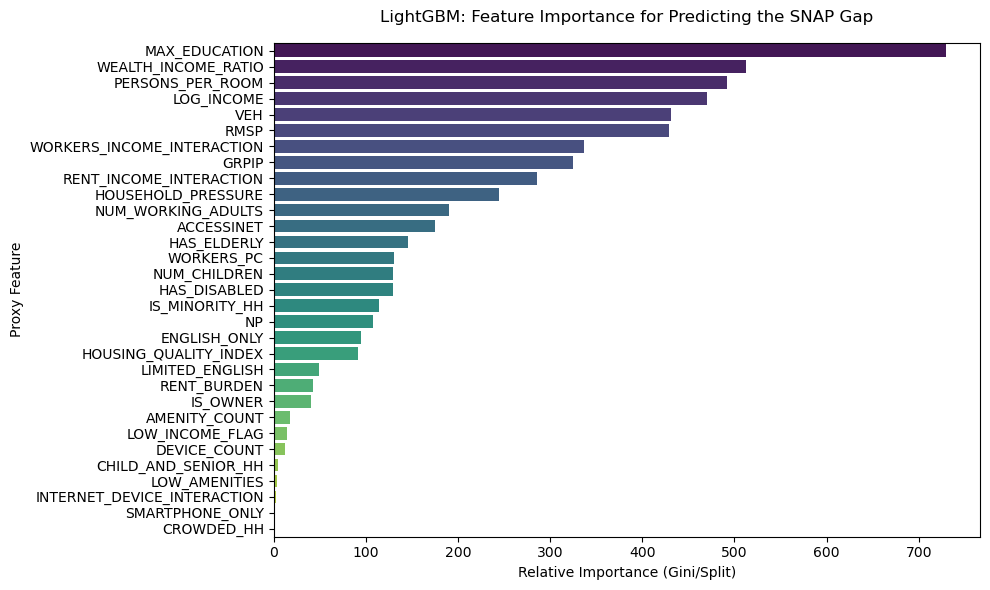

In [73]:
# %%
print(f"\n[ANALYSIS] Step 10: Extracting Feature Importances from {champion_name}...")

# Check if the champion is a tree-based model (LR doesn't have feature_importances_)
if champion_name in ['Random Forest', 'LightGBM','XGBoost']:
    # Extract importances
    importances = champion_model.feature_importances_
    
    # Create a DataFrame for clean display
    df_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    
    # Sort from most important to least
    df_importance = df_importance.sort_values(by='Importance', ascending=False)
    
    print(f"\n[INFO] Top Predictors of the SNAP Gap according to {champion_name}:")
    display(df_importance)

    # Plot the Feature Importances
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='Importance', 
        y='Feature', 
        data=df_importance, 
        hue='Feature', 
        palette='viridis', 
        legend=False
    )
    plt.title(f'{champion_name}: Feature Importance for Predicting the SNAP Gap', pad=15)
    plt.xlabel('Relative Importance (Gini/Split)')
    plt.ylabel('Proxy Feature')
    plt.tight_layout()
    plt.show()

else:
    print("[INFO] Champion is Logistic Regression. Please refer to the Step 5 Coefficients plot.")

[INIT] Step 11: Calculating SHAP Values dynamically for LightGBM...
[SUCCESS] SHAP values successfully calculated for LightGBM.


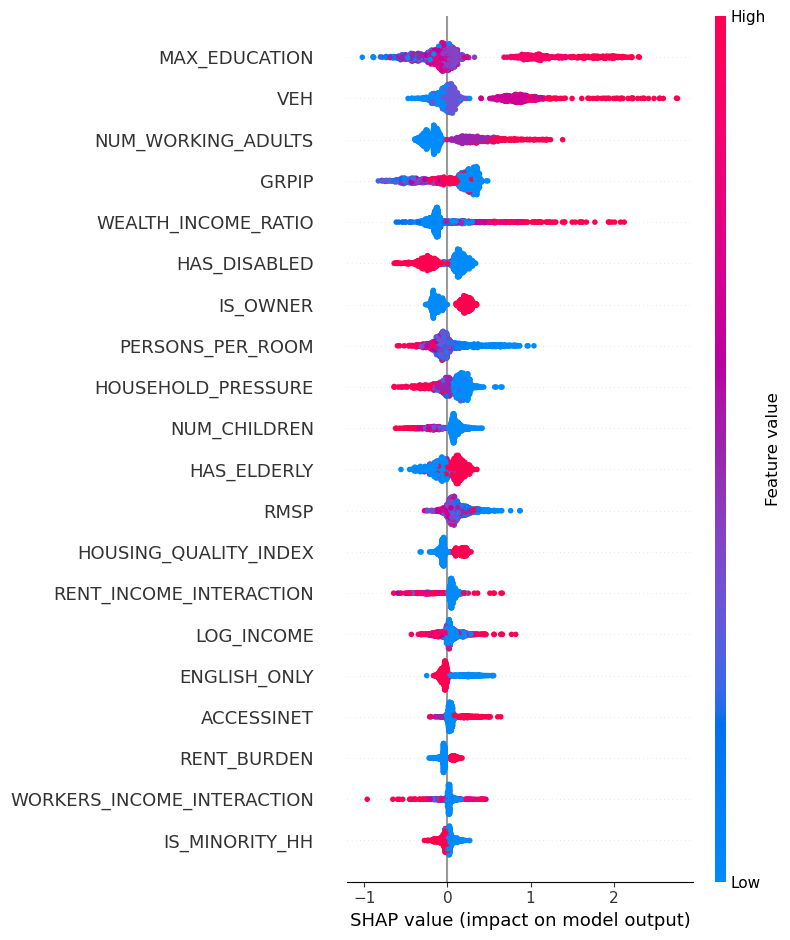

In [74]:
import shap
import pandas as pd
import xgboost as xgb

print(f"[INIT] Step 11: Calculating SHAP Values dynamically for {champion_name}...")

# Convert the scaled numpy array back to a DataFrame so our plot has clean feature names
X_val_df = pd.DataFrame(X_val_scaled, columns=X.columns)

# ==========================================
# 1. LOGISTIC REGRESSION (Linear Model)
# ==========================================
if champion_name == 'Logistic Regression':
    # Linear models require LinearExplainer, not TreeExplainer
    explainer = shap.LinearExplainer(champion_model, X_val_df)
    shap_values = explainer.shap_values(X_val_df)
    shap_values_gap = shap_values

# ==========================================
# 2. XGBOOST (Native C++ Bypass)
# ==========================================
elif champion_name == 'XGBoost':
    # Bypass the SHAP library's Python parser bug by using XGBoost's native SHAP calculator
    dval = xgb.DMatrix(X_val_df)
    booster = champion_model.get_booster()
    raw_shap = booster.predict(dval, pred_contribs=True)
    # Strip off the base_score (last column) to get pure feature contributions
    shap_values_gap = raw_shap[:, :-1]

# ==========================================
# 3. RANDOM FOREST & LIGHTGBM (Standard Trees)
# ==========================================
elif champion_name in ['Random Forest', 'LightGBM']:
    # Standard TreeExplainer works perfectly for these
    explainer = shap.TreeExplainer(champion_model)
    shap_values = explainer.shap_values(X_val_df)
    
    # Isolate the SHAP values for Class 1 (The Gap/Positive Class)
    if isinstance(shap_values, list):
        shap_values_gap = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_gap = shap_values[:, :, 1]
    else:
        shap_values_gap = shap_values

print(f"[SUCCESS] SHAP values successfully calculated for {champion_name}.")

# Generate the beautiful SHAP Summary Plot
shap.summary_plot(shap_values_gap, X_val_df, plot_type="dot")


[INIT] Step 12: Final Unbiased Evaluation on the Test Set...
[SUCCESS] FINAL TEST ROC-AUC: 0.7988

[INFO] Final Classification Report (Test Set):
                precision    recall  f1-score   support

Not in Gap (0)       0.64      0.65      0.64       378
   The Gap (1)       0.82      0.81      0.81       740

      accuracy                           0.75      1118
     macro avg       0.73      0.73      0.73      1118
  weighted avg       0.76      0.75      0.76      1118

[INFO] Generating Final Test Confusion Matrix...


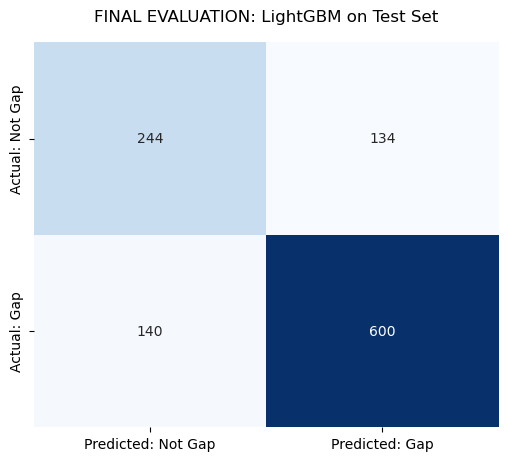

In [75]:
# %%
print("\n[INIT] Step 12: Final Unbiased Evaluation on the Test Set...")

# 1. Predict classes and probabilities using the Champion Model on the unseen TEST data
y_test_pred = champion_model.predict(X_test_scaled)
y_test_probs = champion_model.predict_proba(X_test_scaled)[:, 1]

# 2. Calculate Final ROC-AUC
final_auc = roc_auc_score(y_test, y_test_probs)

print("==================================================")
print(f"[SUCCESS] FINAL TEST ROC-AUC: {final_auc:.4f}")
print("==================================================\n")

# 3. Print Final Classification Report
print("[INFO] Final Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=["Not in Gap (0)", "The Gap (1)"]))

# 4. Visual Confusion Matrix for the Test Set
print("[INFO] Generating Final Test Confusion Matrix...")
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Predicted: Not Gap", "Predicted: Gap"],
            yticklabels=["Actual: Not Gap", "Actual: Gap"])
plt.title(f'FINAL EVALUATION: {champion_name} on Test Set', pad=15)
plt.show()